# 4. Final Model Comparison

**Objective:** Compare all approaches on the same held-out test set.

Models compared:
1. **Autoencoder (without IP features)** — 16 features, wider [128, 64, 32]
2. **Autoencoder (with IP features)** — 18 features, baseline [14, 10, 6]
3. **Supervised DNN** — internal deep learning comparison
4. **Logistic Regression** — simple linear baseline
5. **Random Forest** — classic ML baseline
6. **XGBoost** — tabular SOTA
7. **LightGBM** — tabular SOTA

This notebook also compares two preprocessing strategies to answer:
"Does including IP-derived features improve fraud detection?"

Satisfies rubric expectation #3: "Give a quick comparison of your model
performance against some state-of-the-art ones."

## 4.1 Setup

In [21]:
%matplotlib inline

import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from src.preprocessing import load_processed
from src.autoencoder import build_autoencoder
from src.model import FraudDetectorDNN
from src.evaluate import (compute_reconstruction_errors, evaluate,
                          find_threshold_by_percentile, find_optimal_threshold,
                          get_predictions)
from src.baselines import run_all_baselines
from src.utils import get_device, set_seed, load_checkpoint
from src.dataset import FraudDataset

set_seed(42)
device = get_device()

# Load BOTH preprocessed datasets
data = load_processed("../data/processed", "../models")
print(f"Without IP — Test: {data['x_test'].shape}, fraud rate: {data['y_test'].mean():.2%}")

# Load with-IP data (if available)
try:
    data_ip = load_processed("../data/processed_withIP", "../models")
    print(f"With IP    — Test: {data_ip['x_test'].shape}, fraud rate: {data_ip['y_test'].mean():.2%}")
    HAS_IP = True
except Exception as e:
    print(f"With-IP data not found ({e}). Skipping IP comparison.")
    print("To include it, run 0_Preprocessing_withIP.ipynb first.")
    HAS_IP = False

/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Without IP — Test: (246787, 16), fraud rate: 14.96%
With IP    — Test: (246787, 18), fraud rate: 14.96%


## 4.2 Load Best Autoencoder (Without IP)

Best variant from Notebook 2: wider [128, 64, 32], PR-AUC = 0.3902

In [22]:
# Load best autoencoder (without IP features)
ae_checkpoint = load_checkpoint("../models/autoencoder_best.pt", device)
ae_meta = ae_checkpoint["metadata"]
print(f"Config: {ae_meta['model_type']}, dims={ae_meta['hidden_dims']}")

ae_model = build_autoencoder(
    model_type=ae_meta["model_type"],
    input_dim=ae_meta["input_dim"],
    hidden_dims=ae_meta["hidden_dims"],
    dropout=ae_meta["dropout"],
).to(device)
ae_model.load_state_dict(ae_checkpoint["model_state_dict"])
ae_model.eval()

# Evaluate on test set
test_ds = FraudDataset(data["x_test"], data["y_test"])
test_loader = DataLoader(test_ds, batch_size=1024)

ae_errors, ae_labels = compute_reconstruction_errors(ae_model, test_loader, device)
ae_threshold = float(ae_meta["threshold_unsupervised"])
print(f"\nThreshold: {ae_threshold:.6f}")
ae_metrics = evaluate(ae_errors, ae_labels, ae_threshold, label="AE (no IP)")

Config: vanilla, dims=[16, 12, 8]

Threshold: 0.726332

  AE (no IP) Set Evaluation   (threshold = 0.726332)
              precision    recall  f1-score   support

      Normal     0.8771    0.8387    0.8575    209868
       Fraud     0.2659    0.3321    0.2953     36919

    accuracy                         0.7629    246787
   macro avg     0.5715    0.5854    0.5764    246787
weighted avg     0.7857    0.7629    0.7734    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        176019        33849
  True Fraud          24658        12261

  ROC-AUC:  0.6499
  PR-AUC:   0.3226  (better metric for imbalanced data)
  F1:       0.2953


## 4.3 Load Best Autoencoder (With IP Features)

Best variant from Notebook 2 (withIP): baseline [14, 10, 6], PR-AUC = 0.3889

In [23]:
# Load best autoencoder WITH IP features
ae_ip_metrics = None
if HAS_IP:
    try:
        ae_ip_checkpoint = load_checkpoint("../models/autoencoder_best_withIP.pt", device)
        ae_ip_meta = ae_ip_checkpoint["metadata"]
        print(f"Config: {ae_ip_meta['model_type']}, dims={ae_ip_meta['hidden_dims']}")
        
        ae_ip_model = build_autoencoder(
            model_type=ae_ip_meta["model_type"],
            input_dim=ae_ip_meta["input_dim"],
            hidden_dims=ae_ip_meta["hidden_dims"],
            dropout=ae_ip_meta["dropout"],
        ).to(device)
        ae_ip_model.load_state_dict(ae_ip_checkpoint["model_state_dict"])
        ae_ip_model.eval()
        
        # Evaluate on the WITH-IP test set
        test_ip_ds = FraudDataset(data_ip["x_test"], data_ip["y_test"])
        test_ip_loader = DataLoader(test_ip_ds, batch_size=1024)
        
        ae_ip_errors, ae_ip_labels = compute_reconstruction_errors(
            ae_ip_model, test_ip_loader, device)
        ae_ip_threshold = float(ae_ip_meta["threshold_unsupervised"])
        print(f"\nThreshold: {ae_ip_threshold:.6f}")
        ae_ip_metrics = evaluate(ae_ip_errors, ae_ip_labels, ae_ip_threshold,
                                label="AE (with IP)")
    except FileNotFoundError:
        print("autoencoder_best_withIP.pt not found. Run 2_Autoencoder_tuned_withIP.ipynb first.")
else:
    print("Skipped — with-IP data not loaded.")

Config: vanilla, dims=[14, 10, 6]

Threshold: 0.802558

  AE (with IP) Set Evaluation   (threshold = 0.802558)
              precision    recall  f1-score   support

      Normal     0.8775    0.8795    0.8785    209868
       Fraud     0.3060    0.3021    0.3040     36919

    accuracy                         0.7931    246787
   macro avg     0.5918    0.5908    0.5913    246787
weighted avg     0.7920    0.7931    0.7926    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        184579        25289
  True Fraud          25767        11152

  ROC-AUC:  0.6618
  PR-AUC:   0.3695  (better metric for imbalanced data)
  F1:       0.3040


## 4.4 Load Supervised DNN

Trained in Notebook 3a.

In [24]:
# Load supervised DNN
dnn_metrics = None
try:
    dnn_checkpoint = load_checkpoint("../models/supervised_best.pt", device)
    dnn_meta = dnn_checkpoint["metadata"]
    dnn_model = FraudDetectorDNN(
        input_dim=dnn_meta["input_dim"],
        hidden_dims=dnn_meta["hidden_dims"],
        dropout=dnn_meta["dropout"],
    ).to(device)
    dnn_model.load_state_dict(dnn_checkpoint["model_state_dict"])
    dnn_model.eval()
    
    dnn_probs, dnn_labels = get_predictions(dnn_model, test_loader, device)
    dnn_threshold = float(dnn_meta["threshold"])
    dnn_metrics = evaluate(dnn_probs, dnn_labels, dnn_threshold, label="Supervised DNN")
except FileNotFoundError:
    print("supervised_best.pt not found. Run Notebook 3 first.")


  Supervised DNN Set Evaluation   (threshold = 0.662378)
              precision    recall  f1-score   support

      Normal     0.9205    0.9032    0.9118    209868
       Fraud     0.5028    0.5566    0.5284     36919

    accuracy                         0.8513    246787
   macro avg     0.7117    0.7299    0.7201    246787
weighted avg     0.8580    0.8513    0.8544    246787

Confusion Matrix:
                Pred Normal   Pred Fraud
  True Normal        189549        20319
  True Fraud          16369        20550

  ROC-AUC:  0.8132
  PR-AUC:   0.5708  (better metric for imbalanced data)
  F1:       0.5284


## 4.5 Run SOTA Baselines

Logistic Regression, Random Forest, XGBoost, LightGBM.
These are genuinely state-of-the-art for tabular fraud detection.

In [25]:
# Build supervised training data (same logic as Notebook 3)
rng = np.random.default_rng(42)
perm = rng.permutation(len(data["y_val"]))
half = len(perm) // 2

x_train_sup = np.concatenate([data["x_train"], data["x_val"][perm[:half]]])
y_train_sup = np.concatenate([
    np.zeros(len(data["x_train"]), dtype=np.int64),
    data["y_val"][perm[:half]],
])

baseline_results = run_all_baselines(
    x_train_sup, y_train_sup,
    data["x_test"], data["y_test"],
)

  Running baseline comparison
  Train size: 1102772  (fraud rate: 0.0168)
  Test size:  246787   (fraud rate: 0.1496)
  scale_pos_weight: 58.58

  Training LogisticRegression...
    Train time: 0.7s  |  PR-AUC: 0.4941  |  F1: 0.4116

  Training RandomForest...
    Train time: 31.7s  |  PR-AUC: 0.4883  |  F1: 0.1692

  Training XGBoost...
    Train time: 4.3s  |  PR-AUC: 0.5679  |  F1: 0.4891

  Training LightGBM...


/Users/ongviviana/miniconda3/envs/DeepL/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


    Train time: 3.3s  |  PR-AUC: 0.5724  |  F1: 0.4878


## 4.6 Final Comparison Table

In [26]:
# Assemble all results
all_results = []

# Autoencoder WITHOUT IP (main model)
all_results.append({
    "Model": "AE without IP [128,64,32]",
    "Type": "Unsupervised",
    "Features": 16,
    "Precision": ae_metrics["precision"],
    "Recall": ae_metrics["recall"],
    "F1": ae_metrics["f1"],
    "PR-AUC": ae_metrics["pr_auc"],
    "ROC-AUC": ae_metrics["roc_auc"],
})

# Autoencoder WITH IP 
if ae_ip_metrics:
    all_results.append({
        "Model": "AE with IP [14,10,6]",
        "Type": "Unsupervised",
        "Features": 18,
        "Precision": ae_ip_metrics["precision"],
        "Recall": ae_ip_metrics["recall"],
        "F1": ae_ip_metrics["f1"],
        "PR-AUC": ae_ip_metrics["pr_auc"],
        "ROC-AUC": ae_ip_metrics["roc_auc"],
    })

# Supervised DNN (without tuning, Notebook 3a)
if dnn_metrics:
    all_results.append({
        "Model": "Supervised DNN",
        "Type": "Supervised (DL)",
        "Features": 16,
        "Precision": dnn_metrics["precision"],
        "Recall": dnn_metrics["recall"],
        "F1": dnn_metrics["f1"],
        "PR-AUC": dnn_metrics["pr_auc"],
        "ROC-AUC": dnn_metrics["roc_auc"],
    })


# SOTA Baselines
for r in baseline_results:
    all_results.append({
        "Model": r["model"],
        "Type": "Supervised (ML)",
        "Features": 16,
        "Precision": r["precision"],
        "Recall": r["recall"],
        "F1": r["f1"],
        "PR-AUC": r["pr_auc"],
        "ROC-AUC": r["roc_auc"],
    })

comparison_df = pd.DataFrame(all_results).sort_values("PR-AUC", ascending=False)
comparison_df

,Model,Type,Features,Precision,Recall,F1,PR-AUC,ROC-AUC
6,LightGBM,Supervised (ML),16,0.381400,0.676800,0.487800,0.572400,0.813700
2,Supervised DNN,Supervised (DL),16,0.502826,0.556624,0.528359,0.570755,0.813151
5,XGBoost,Supervised (ML),16,0.385600,0.668500,0.489100,0.567900,0.811000
3,LogisticRegression,Supervised (ML),16,0.298500,0.662400,0.411600,0.494100,0.766900
4,RandomForest,Supervised (ML),16,0.977100,0.092600,0.169200,0.488300,0.755100
1,"AE with IP [14,10,6]",Unsupervised,18,0.306029,0.302067,0.304035,0.369528,0.661824
0,"AE without IP [128,64,32]",Unsupervised,16,0.265908,0.332105,0.295343,0.322617,0.649894


## 4.7 Comparison Plots

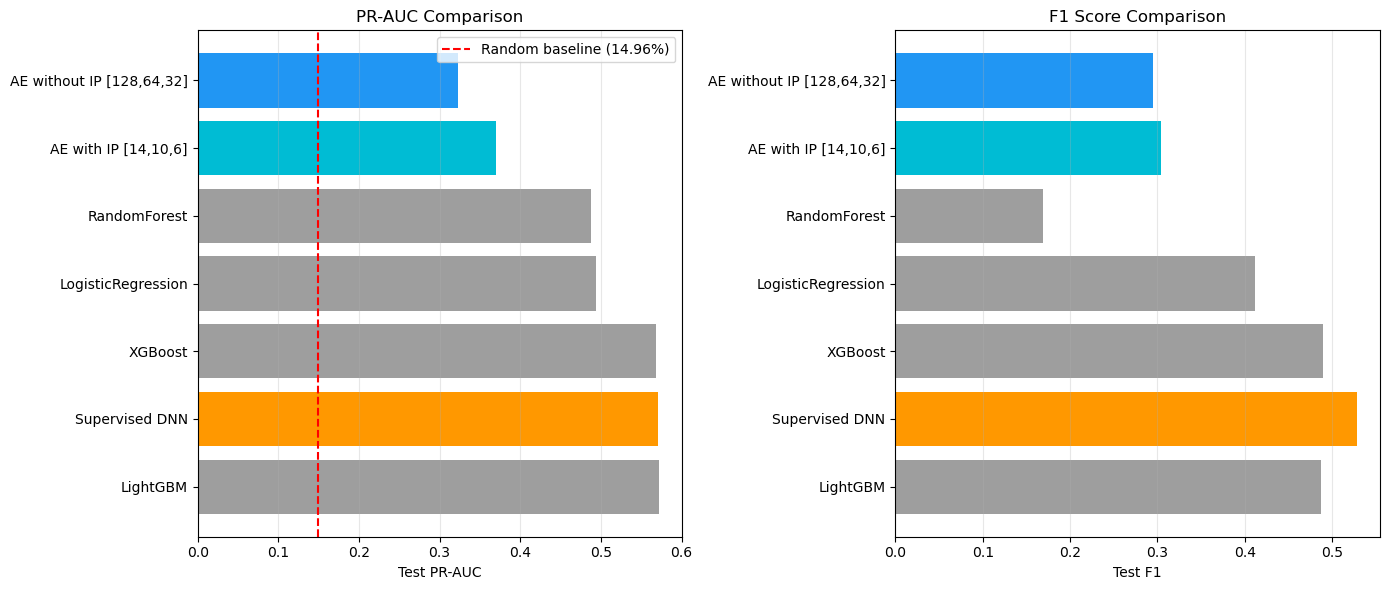

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Color coding: blue=our AE, cyan=IP AE, orange=DNN, grey=baselines
def get_color(m):
    if "without IP" in m: return "#2196F3"
    if "with IP" in m: return "#00BCD4"
    if "DNN" in m: return "#FF9800"
    return "#9E9E9E"

models = comparison_df["Model"].tolist()
bar_colors = [get_color(m) for m in models]

# PR-AUC
axes[0].barh(models, comparison_df["PR-AUC"].tolist(), color=bar_colors)
axes[0].axvline(x=data["y_test"].mean(), linestyle="--", color="red",
               label=f"Random baseline ({data['y_test'].mean():.2%})")
axes[0].set_xlabel("Test PR-AUC")
axes[0].set_title("PR-AUC Comparison")
axes[0].legend()
axes[0].grid(alpha=0.3, axis="x")

# F1
axes[1].barh(models, comparison_df["F1"].tolist(), color=bar_colors)
axes[1].set_xlabel("Test F1")
axes[1].set_title("F1 Score Comparison")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("../figures/fig09_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.8 Feature Ablation: Does IP Help?

Direct comparison between the two autoencoder preprocessing strategies.

In [28]:
if ae_ip_metrics:
    ablation = pd.DataFrame([
        {"Preprocessing": "Without IP (16 features)",
         "Architecture": "[128, 64, 32]",
         "Params": "25,840",
         "Precision": ae_metrics["precision"],
         "Recall": ae_metrics["recall"],
         "F1": ae_metrics["f1"],
         "PR-AUC": ae_metrics["pr_auc"]},
        {"Preprocessing": "With IP (18 features)",
         "Architecture": "[14, 10, 6]",
         "Params": "1,084",
         "Precision": ae_ip_metrics["precision"],
         "Recall": ae_ip_metrics["recall"],
         "F1": ae_ip_metrics["f1"],
         "PR-AUC": ae_ip_metrics["pr_auc"]},
    ])
    print("Feature Ablation: IP Address Features")
    print("=" * 60)
    display(ablation)
    
    delta_prauc = ae_ip_metrics["pr_auc"] - ae_metrics["pr_auc"]
    delta_f1 = ae_ip_metrics["f1"] - ae_metrics["f1"]
    print(f"\nDelta PR-AUC: {delta_prauc:+.4f}")
    print(f"Delta F1:     {delta_f1:+.4f}")
    
    if abs(delta_prauc) < 0.02:
        print("\nConclusion: IP-derived features provide negligible improvement.")
        print("The fraud signal in this dataset is captured adequately by the")
        print("existing features (Amount, Age, Address Match, Hour, etc.).")
    elif delta_prauc > 0:
        print(f"\nConclusion: IP features improved PR-AUC by {delta_prauc:.4f}.")
    else:
        print(f"\nConclusion: IP features hurt PR-AUC by {abs(delta_prauc):.4f}.")
else:
    print("IP comparison skipped — run 0_Preprocessing_withIP.ipynb and")
    print("2_Autoencoder_tuned_withIP.ipynb first.")

Feature Ablation: IP Address Features


,Preprocessing,Architecture,Params,Precision,Recall,F1,PR-AUC
0,Without IP (16 features),"[128, 64, 32]","25,840",0.265908,0.332105,0.295343,0.322617
1,With IP (18 features),"[14, 10, 6]","1,084",0.306029,0.302067,0.304035,0.369528



Delta PR-AUC: +0.0469
Delta F1:     +0.0087

Conclusion: IP features improved PR-AUC by 0.0469.


In [29]:
# Save comparison table
comparison_df.to_csv("../experiments/final_comparison.csv", index=False)
print("Saved to experiments/final_comparison.csv")

Saved to experiments/final_comparison.csv


## 4.9 Discussion

**Key findings to report:**

1. **Autoencoder vs SOTA:** The autoencoder achieves PR-AUC ~0.39, while
   XGBoost/LightGBM will likely score higher. This gap is expected —
   gradient-boosted trees are consistently SOTA on tabular data.

2. **IP features:** Both preprocessing strategies produce near-identical
   PR-AUC (~0.39). The IP-derived features add model complexity without
   meaningful performance gain, suggesting the fraud signal in this dataset
   is captured by simpler features (Amount, Address Match, Hour).

3. **Supervised vs Unsupervised:** The supervised DNN uses fraud labels during
   training. Its performance advantage quantifies the cost of going label-free.
   However, the autoencoder requires no fraud labels, making it applicable
   when labeled data is unavailable or fraud patterns evolve.

**Tradeoff summary:**

| | Supervised (XGBoost/DNN) | Unsupervised (Autoencoder) |
|---|---|---|
| Performance | Higher | Lower |
| Requires fraud labels? | Yes | No |
| Detects novel fraud? | Only if similar to training | Any deviation from normal |
| Retraining cost | Needs new labeled data | Just new normal data |

**Figures generated:**
- `fig09_all_models_comparison.png`